In [1]:
# import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import zscore
%matplotlib inline

In [2]:
# load the dataset
togo=pd.read_csv('../data/togo-dapaong_qc.csv')
togo.head()

,Timestamp,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
0,2021-10-25 00:01,-1.3,0.0,0.0,0.0,0.0,24.8,94.5,0.9,1.1,0.4,227.6,1.1,977,0,0.0,24.7,24.4,NaN
1,2021-10-25 00:02,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.1,1.6,0.4,229.3,0.7,977,0,0.0,24.7,24.4,NaN
2,2021-10-25 00:03,-1.3,0.0,0.0,0.0,0.0,24.8,94.4,1.2,1.4,0.3,228.5,2.9,977,0,0.0,24.7,24.4,NaN
3,2021-10-25 00:04,-1.2,0.0,0.0,0.0,0.0,24.8,94.3,1.2,1.6,0.3,229.1,4.6,977,0,0.0,24.7,24.4,NaN
4,2021-10-25 00:05,-1.2,0.0,0.0,0.0,0.0,24.8,94.0,1.3,1.6,0.4,227.5,1.6,977,0,0.0,24.7,24.4,NaN


In [3]:
togo.dtypes# check what the datatypes of each columns are

Timestamp         object
GHI              float64
DNI              float64
DHI              float64
ModA             float64
ModB             float64
Tamb             float64
RH               float64
WS               float64
WSgust           float64
WSstdev          float64
WD               float64
WDstdev          float64
BP                 int64
Cleaning           int64
Precipitation    float64
TModA            float64
TModB            float64
Comments         float64
dtype: object

###  Summery of  Statistics and Missing Value Report

In [4]:
# describe the dataset to get summery statistics
togo.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,230.555040,151.258469,116.444352,226.144375,219.568588,27.751788,55.013160,2.368093,3.229490,0.557740,161.741845,10.559568,975.915242,0.000535,0.001382,32.444403,33.543330,NaN
std,322.532347,250.956962,156.520714,317.346938,307.932510,4.758023,28.778732,1.462668,1.882565,0.268923,91.877217,5.915490,2.153977,0.023116,0.026350,10.998334,12.769277,NaN
min,-12.700000,0.000000,0.000000,0.000000,0.000000,14.900000,3.300000,0.000000,0.000000,0.000000,0.000000,0.000000,968.000000,0.000000,0.000000,13.100000,13.100000,NaN
25%,-2.200000,0.000000,0.000000,0.000000,0.000000,24.200000,26.500000,1.400000,1.900000,0.400000,74.800000,6.900000,975.000000,0.000000,0.000000,23.900000,23.600000,NaN
50%,2.100000,0.000000,2.500000,4.400000,4.300000,27.200000,59.300000,2.200000,2.900000,0.500000,199.100000,10.800000,976.000000,0.000000,0.000000,28.400000,28.400000,NaN
75%,442.400000,246.400000,215.700000,422.525000,411.000000,31.100000,80.800000,3.200000,4.400000,0.700000,233.500000,14.100000,977.000000,0.000000,0.000000,40.600000,43.000000,NaN
max,1424.000000,1004.500000,805.700000,1380.000000,1367.000000,41.400000,99.800000,16.100000,23.100000,4.700000,360.000000,86.900000,983.000000,1.000000,2.300000,70.400000,94.600000,NaN


In [5]:
# missing value report 
missing_values=togo.isna().sum()
missing_values


Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [6]:
# convert missing values to percentage
missing_percentage=(missing_values/len(togo))*100 
missing_percentage

Timestamp          0.0
GHI                0.0
DNI                0.0
DHI                0.0
ModA               0.0
ModB               0.0
Tamb               0.0
RH                 0.0
WS                 0.0
WSgust             0.0
WSstdev            0.0
WD                 0.0
WDstdev            0.0
BP                 0.0
Cleaning           0.0
Precipitation      0.0
TModA              0.0
TModB              0.0
Comments         100.0
dtype: float64

In [7]:
# return columns with missing value > 5%
for col, perc in missing_percentage.items():
    if perc > 5:
        print(f"{col}: {perc} %")

Comments: 100.0 %


In [8]:
# let's save copy of the original data
togo_cp=togo.copy()
# drop columns with more than 5% missing values
togo_cp=togo_cp.drop('Comments', axis=1)

In [9]:
# list of  important numerical columns
num_cols=['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb']

In [10]:
# check the outliers in numerical columns 
oulire_flag = np.abs(zscore(togo_cp[num_cols])) 
outliers = (oulire_flag > 3).any(axis=1)
togo_cp['Outlires'] = outliers
togo_cp['Outlires'].value_counts()

Outlires
False    520853
True       4747
Name: count, dtype: int64

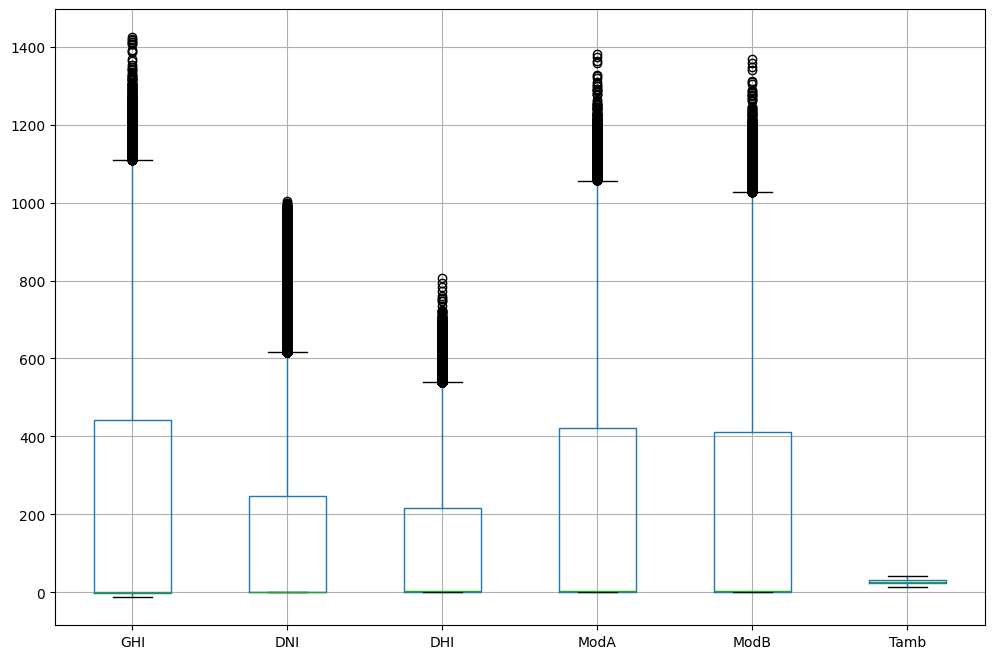

In [11]:
# plot boxplot for numeric cols
togo_cp.boxplot(num_cols,figsize=(12,8));

In [12]:
# export cleaned data
togo_cp.to_csv('../data/togo_cp-cleaned.csv',index=False)

### Time Analysis

In [13]:
# convert Timestamp to datetime format
togo_cp['Timestamp']=pd.to_datetime(togo_cp['Timestamp'])
# set Tiemstamp as index
togo_cp.set_index('Timestamp',inplace=True)


### Timestamp Plots

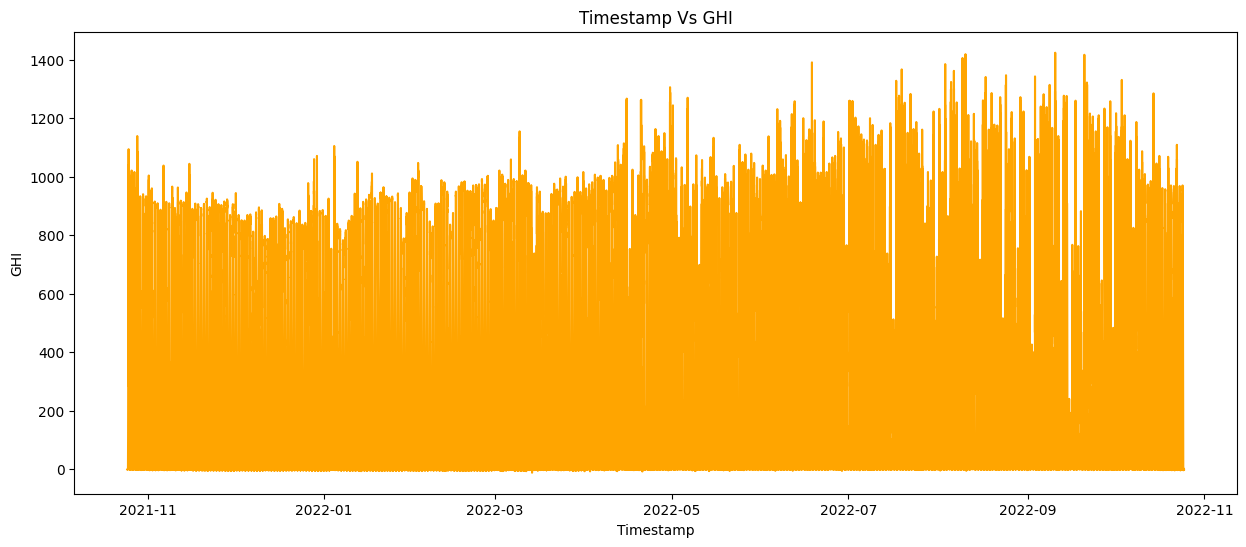

In [14]:
# Timestamp Vs GHI plot
plt.figure(figsize=(15,6))
plt.plot(togo_cp.index,togo_cp["GHI"],color='orange')
plt.title('Timestamp Vs GHI')
plt.xlabel('Timestamp')
plt.ylabel('GHI')
plt.show()

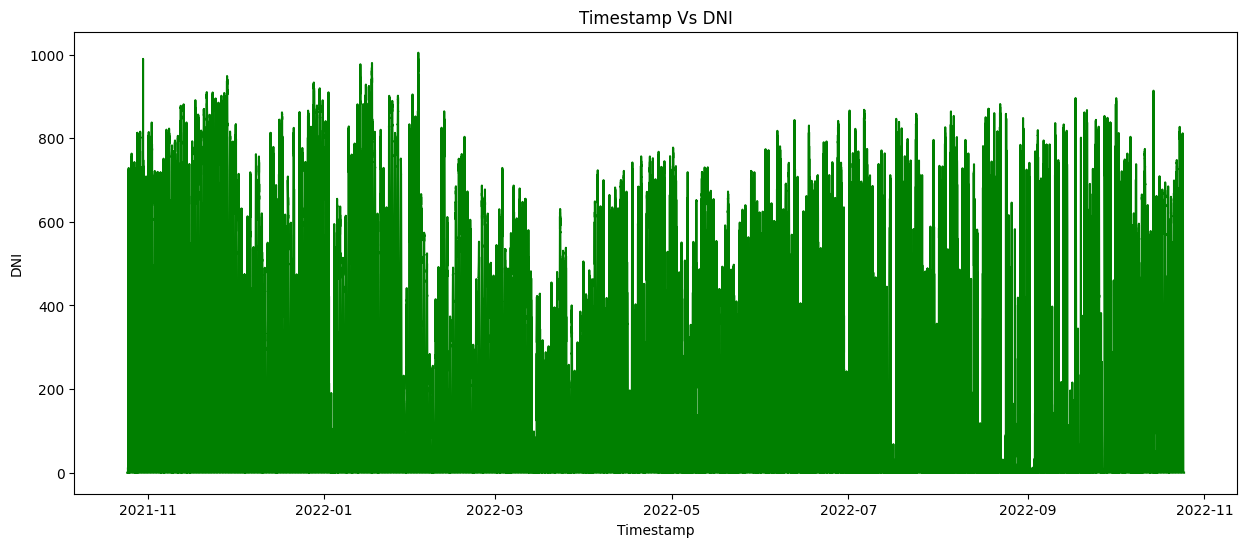

In [15]:
# Timestamp vs DNI plot
plt.figure(figsize=(15,6))
plt.plot(togo_cp.index,togo_cp["DNI"],color='green')
plt.title('Timestamp Vs DNI')
plt.xlabel('Timestamp')
plt.ylabel('DNI')
plt.show()

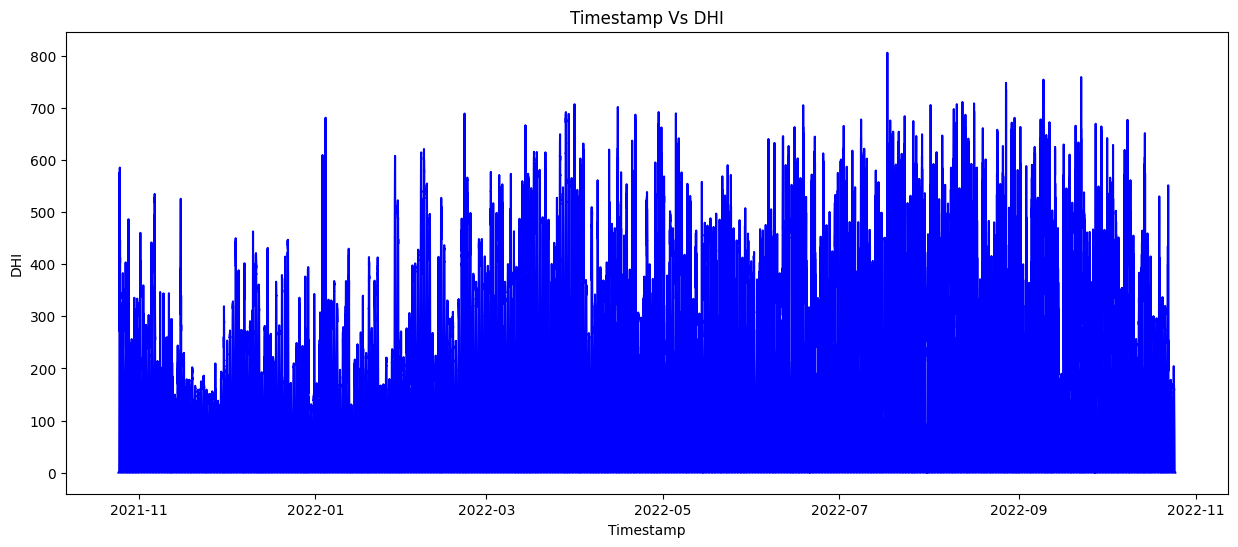

In [17]:
# Timestamp vs DHI plot
plt.figure(figsize=(15,6))
plt.plot(togo_cp.index,togo_cp["DHI"],color='blue')
plt.title('Timestamp Vs DHI')
plt.xlabel('Timestamp')
plt.ylabel('DHI')
plt.show()

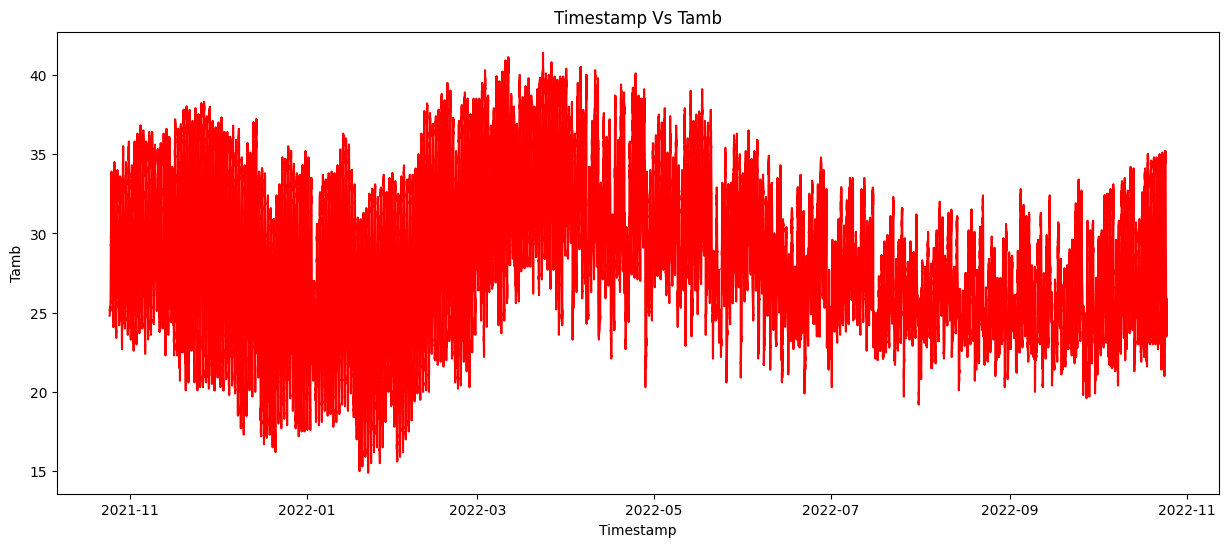

In [18]:
# Timestamp vs Tamb plot
plt.figure(figsize=(15,6))
plt.plot(togo_cp.index,togo_cp["Tamb"],color='red')
plt.title('Timestamp Vs Tamb')
plt.xlabel('Timestamp')
plt.ylabel('Tamb')
plt.show()

In [19]:
# obsernve patterns in months
togo_cp['Month']=togo_cp.index.month # extract month from timestamp
# compute monthly average for numeric columns
monthly_avg=togo_cp.groupby('Month')[num_cols].mean()
monthly_avg

,GHI,DNI,DHI,ModA,ModB,Tamb
Month,,,,,,
1,238.426918,219.422166,90.369834,252.793757,247.340795,25.132681
2,257.658819,172.229457,131.359266,266.017083,253.203924,28.268621
3,252.169276,114.931635,157.590645,246.409487,229.342254,32.511519
4,252.307278,143.576257,131.567965,233.903743,229.529609,30.888090
5,238.432717,129.297993,128.203943,210.551445,206.382995,29.719371
6,237.576118,133.510521,124.700926,208.298275,205.507266,27.732884
7,203.113380,94.875930,124.710381,181.250930,179.076794,26.264928
8,189.017236,81.059830,123.404628,175.012805,173.186579,25.294935
9,177.739558,83.204699,111.767359,171.627627,169.789213,24.970475


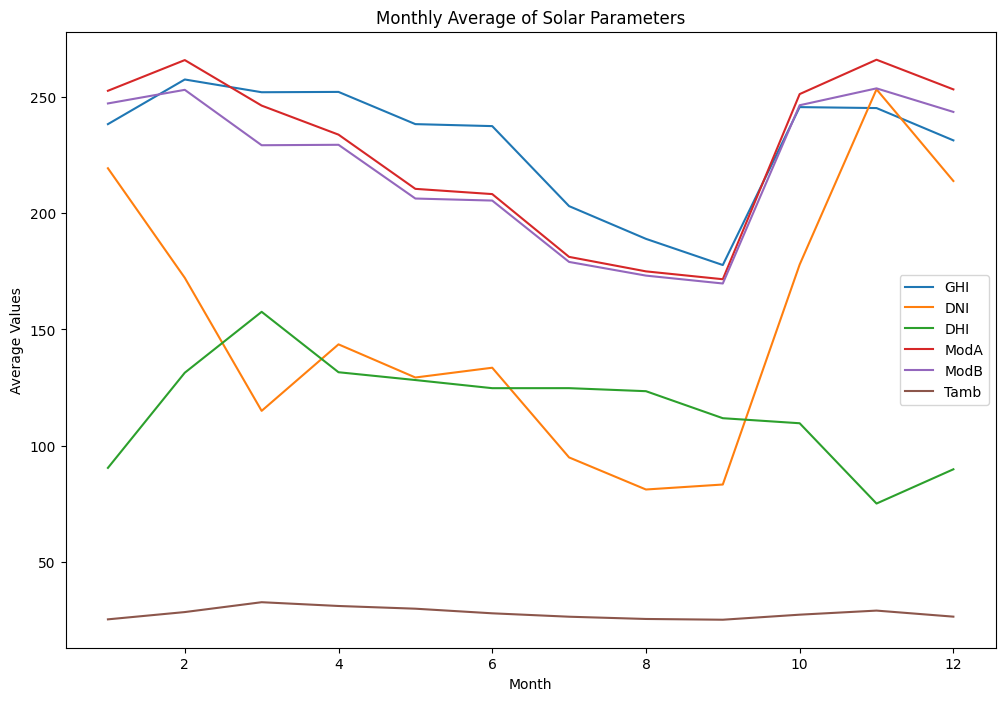

In [20]:
# show monthly pattens plots
monthly_avg.plot(figsize=(12,8))
plt.title('Monthly Average of Solar Parameters')
plt.xlabel('Month')
plt.ylabel('Average Values')
plt.show()

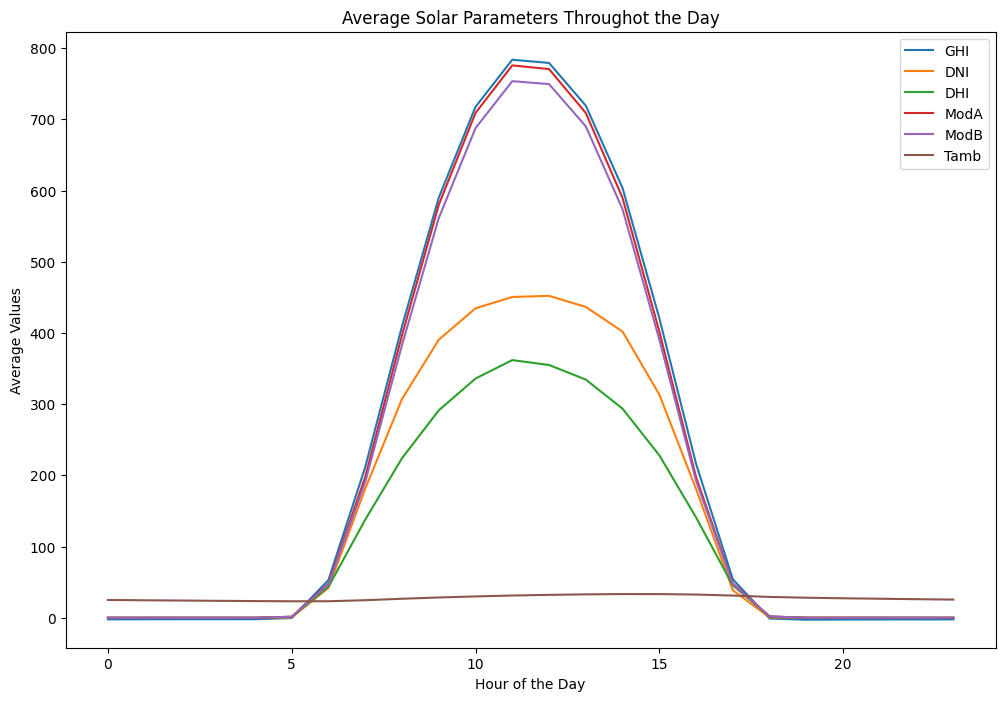

In [21]:
# Trends throughout the day
togo_cp['Hour']=togo_cp.index.hour # extraxt hour from timestamp
daily_avg=togo_cp.groupby('Hour')[num_cols].mean()
daily_avg.plot(figsize=(12,8))
plt.title('Average Solar Parameters Throughot the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Values')
plt.show()

In [22]:
# Detect anomalies in GHI using rolling mean and std deviation
ghi_mean,ghi_std=togo_cp['GHI'].mean(),togo_cp['GHI'].std()
# detect anomalies
togo_cp['GHI_Anomaly']=((togo_cp['GHI']> (ghi_mean + 3*ghi_std)) | (togo_cp['GHI']< (ghi_mean - 3*ghi_std)))
togo_cp['GHI_Anomaly'].value_counts()

GHI_Anomaly
False    525295
True        305
Name: count, dtype: int64

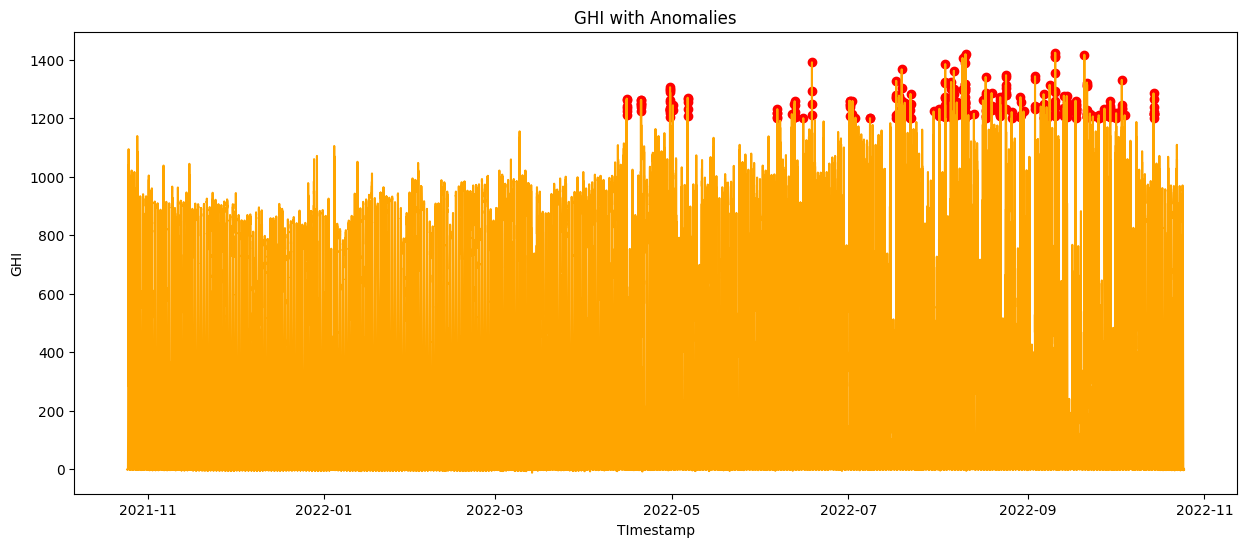

In [23]:
# plot anomalies
plt.figure(figsize=(15,6))
plt.plot(togo_cp.index,togo_cp["GHI"],label='GHI',color='orange')
plt.scatter(
    togo_cp[togo_cp['GHI_Anomaly']].index, 
    togo_cp[togo_cp['GHI_Anomaly']]['GHI'],
    color='red',label='Anomalies')
plt.title('GHI with Anomalies')
plt.xlabel('TImestamp')
plt.ylabel('GHI')
plt.show()